In [1]:
from cvxopt import matrix, solvers
import numpy as np
import matplotlib.pyplot as plt
import mglearn
import pickle
from sklearn.datasets import make_blobs
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.kernel_approximation import Nystroem
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score
import torchvision
from torch.utils.data import DataLoader, Subset
from torchvision import datasets
import torchvision.transforms as transforms
from tqdm import tqdm

np.random.seed(666)
solvers.options['show_progress'] = False

In [2]:
class LSC:
    def __init__(self, alpha=1.0):
        self.w = None # 权重
        self.alpha = alpha # 正则化强度

    def fit(self, X, y):
        self.w = np.linalg.pinv(X.T @ X + self.alpha * np.eye(X.shape[1])) @ X.T @ y

    def predict(self, X):
        return np.sign(np.dot(X, self.w))

class Perceptron:
    def __init__(self, lr=0.001, max_iter=1000):
        self.w = None # 权重
        self.lr = lr # 学习率
        self.max_iter = max_iter # 最大迭代次数
    
    def fit(self, X, y):
        _, n_features = X.shape
        self.w = np.random.uniform(-1, 1, n_features)
        for _ in range(self.max_iter):
            predictions = np.dot(X, self.w)
            errors = y * predictions <= 0
            if not np.any(errors):
                break
            X_errors = X[errors]
            y_errors = y[errors]
            self.w += self.lr * np.dot(X_errors.T, y_errors)

    def predict(self, X):
        return np.sign(np.dot(X, self.w))

class LDA:
    def __init__(self):
        self.w = None # 权重

    def fit(self, X, y):
        class0 = X[y == -1]
        class1 = X[y == 1]
        mean0 = np.mean(class0, axis=0)
        mean1 = np.mean(class1, axis=0)
        S_w = np.cov(class0, rowvar=False) * (class0.shape[0] - 1) + np.cov(class1, rowvar=False) * (class1.shape[0] - 1)
        self.w = np.linalg.pinv(S_w) @ (mean1 - mean0)

    def predict(self, X):
        return np.sign(np.dot(X, self.w))

class SVM:
    def __init__(self, lr=0.001, max_iter=1000):
        self.w = None # 权重
        self.lr = lr # 学习率
        self.max_iter = max_iter # 最大迭代次数
    
    def fit(self, X, y):
        n_samples, n_features = X.shape
        
        if n_samples * n_features < 10000: # 数据量小时直接求解
            K = np.dot(X, X.T) # 核矩阵
            
            # 使用 cvxopt 求解二次规划问题
            P = matrix(np.outer(y, y) * K)  # Pij = yi * yj * Xi^T * Xj
            q = matrix(-np.ones(n_samples))  # 目标函数中的 q 向量
            G = matrix(-np.eye(n_samples))  # G = -I，用于保证 alpha >= 0
            h = matrix(np.zeros(n_samples))  # h 向量，alpha >= 0
            A = matrix(y, (1, n_samples), 'd')  # 约束条件 sum(alpha_i * y_i) = 0
            b = matrix(0.0)  # 约束条件 b = 0
            solution = solvers.qp(P, q, G, h, A, b)
            alpha = np.ravel(solution['x'])  # 拉格朗日乘子

            # 找到支持向量（拉格朗日乘子 > 0）
            support_vector_indices = alpha > 1e-5
            support_vector_alpha = alpha[support_vector_indices]
            support_vectors = X[support_vector_indices]
            support_vector_labels = y[support_vector_indices]

            # 计算权重向量 w = sum(alpha_i * y_i * x_i)
            self.w = np.sum(support_vector_alpha[:, None] * support_vector_labels[:, None] * support_vectors, axis=0)
        
        else: # 数据量大时SGD
            self.w = np.random.uniform(-1, 1, n_features)
            for _ in range(self.max_iter):
                decision_values = y * np.dot(X, self.w)
                condition = decision_values >= 1
                X_misclassified = X[~condition]
                y_misclassified = y[~condition]
                if len(X_misclassified) > 0:
                    gradient = np.dot(X_misclassified.T, y_misclassified)
                    self.w += self.lr * gradient

    def predict(self, X):
        return np.sign(np.dot(X, self.w))

class LogisticRegression:
    def __init__(self, lr=0.01, max_iter=1000):
        self.w = None # 权重
        self.lr = lr # 学习率
        self.max_iter = max_iter # 最大迭代次数

    def sigmoid(self, z):
        return 1 / (1 + np.exp(-z))

    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.w = np.random.uniform(-1, 1, n_features)
        for _ in range(self.max_iter):
            y_pred = self.sigmoid(np.dot(X, self.w))
            gradient = np.dot(X.T, (y_pred - y)) / n_samples
            self.w -= self.lr * gradient

    def predict(self, X):
        return np.sign(self.sigmoid(np.dot(X, self.w)) - 0.5)

class OvR:
    def __init__(self, model_class, **model_kwargs):
        self.model_class = model_class # 模型类
        self.model_kwargs = model_kwargs # 模型参数
        self.models = None # 每个类别的模型实例, 类标签为[0,1,2,...,k-1]
        self.n_classes = None # 类别数量

    def fit(self, X, y):
        self.models = []
        self.n_classes = np.max(y) + 1
        for k in tqdm(range(self.n_classes)):
            model = self.model_class(**self.model_kwargs)
            y_binary = np.where(y == k, 1, -1) # 将当前类别作为正类 (1)，其他类别作为负类 (-1)
            model.fit(X, y_binary)
            self.models.append(model)

    def predict(self, X):
        if X.shape[1] + 1 == self.models[0].w.shape[0]: # 适配mglearn.plots.plot_2d_classification
            X = np.hstack([np.ones((X.shape[0], 1)), X])
        predictions = np.array([X @ model.w for model in self.models]).T
        return np.argmax(predictions, axis=1)

class SoftmaxRegression:
    def __init__(self, lr=0.01, max_iter=1000):
        self.w = None # 权重
        self.lr = lr # 学习率
        self.max_iter = max_iter # 最大迭代次数

    def softmax(self, z):
        exp_z = np.exp(z - np.max(z, axis=1, keepdims=True)) # 数值稳定性处理，减去最大值以防止溢出
        return exp_z / np.sum(exp_z, axis=1, keepdims=True)

    def fit(self, X, y):
        n_samples, n_features = X.shape
        n_classes = np.max(y) + 1
        self.w = np.random.uniform(-1, 1, (n_features, n_classes))
        y_one_hot = np.eye(n_classes)[y] # 使用 one-hot 编码将 y 转换为矩阵形式
        for _ in tqdm(range(self.max_iter)):
            y_pred = self.softmax(np.dot(X, self.w))
            gradient = np.dot(X.T, (y_pred - y_one_hot)) / n_samples
            self.w -= self.lr * gradient

    def predict(self, X):
        if X.shape[1] + 1 == self.w.shape[0]: # 适配mglearn.plots.plot_2d_classification
            X = np.hstack([np.ones((X.shape[0], 1)), X])
        y_pred = self.softmax(np.dot(X, self.w))
        return np.argmax(y_pred, axis=1)

class PolyKernel:
    def __init__(self, model, degree=3, coef0=0, n_components=200):
        self.model = model  # 模型实例
        self.poly_feature = Nystroem(kernel='poly', degree=degree, coef0=coef0, n_components=n_components) # 多项式核近似变换

    def fit(self, X, y):
        X_poly = self.poly_feature.fit_transform(X)
        self.model.fit(X_poly, y)

    def predict(self, X):
        X_poly = self.poly_feature.transform(X)
        return self.model.predict(X_poly)

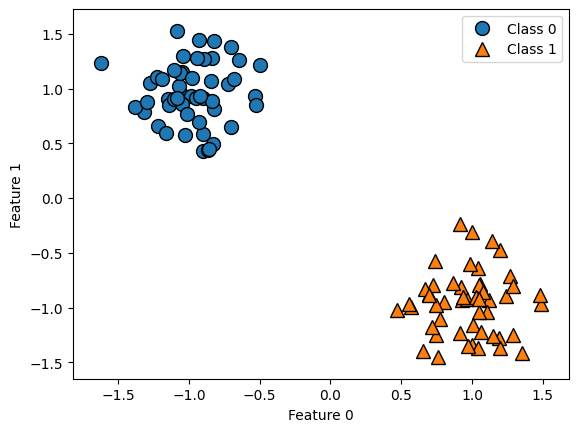

In [3]:
# 生成只有两个类别的二维玩具数据集
X, y = make_blobs(n_samples=100, centers=2, random_state=42)

# 将 y 的取值从默认的 0 和 1 修改为 +1 和 -1
y = np.where(y == 0, -1, 1)

# 对数据进行归一化
scaler = StandardScaler()
X = scaler.fit_transform(X)

# 使用PolynomialFeatures加一列1
poly = PolynomialFeatures(degree=1, include_bias=True)
X = poly.fit_transform(X)

# 可视化数据点
mglearn.discrete_scatter(X[:, 1], X[:, 2], y)
plt.xlabel("Feature 0")
plt.ylabel("Feature 1")
plt.legend(["Class 0", "Class 1"])
plt.show()

In [4]:
def visualize_binary_classification(X, y, models, titles):
    plt.figure(figsize=(16, 8))
    for i, model in enumerate(models):
        plt.subplot(2, 3, i + 1)
        mglearn.discrete_scatter(X[:, 1], X[:, 2], y)
        line = np.linspace(X[:, 1].min() - 1, X[:, 2].max() + 1, 100)
        coef = model.w
        plt.plot(line, -(line * coef[1] + coef[0]) / coef[2], c='b')
        plt.ylim(X[:, 2].min() - 1, X[:, 2].max() + 1)
        plt.xlim(X[:, 1].min() - 1, X[:, 1].max() + 1)
        plt.xlabel("Feature 0")
        plt.ylabel("Feature 1")
        plt.title(f"{titles[i]}")
    plt.tight_layout()
    plt.show()

In [5]:
models = [LSC(), Perceptron(), LDA(), SVM(), LogisticRegression()]
titles = ['LSC', "Perceptron", "LDA", "SVM", "LogisticRegression"]
for _, model in enumerate(models):
    model.fit(X, y)

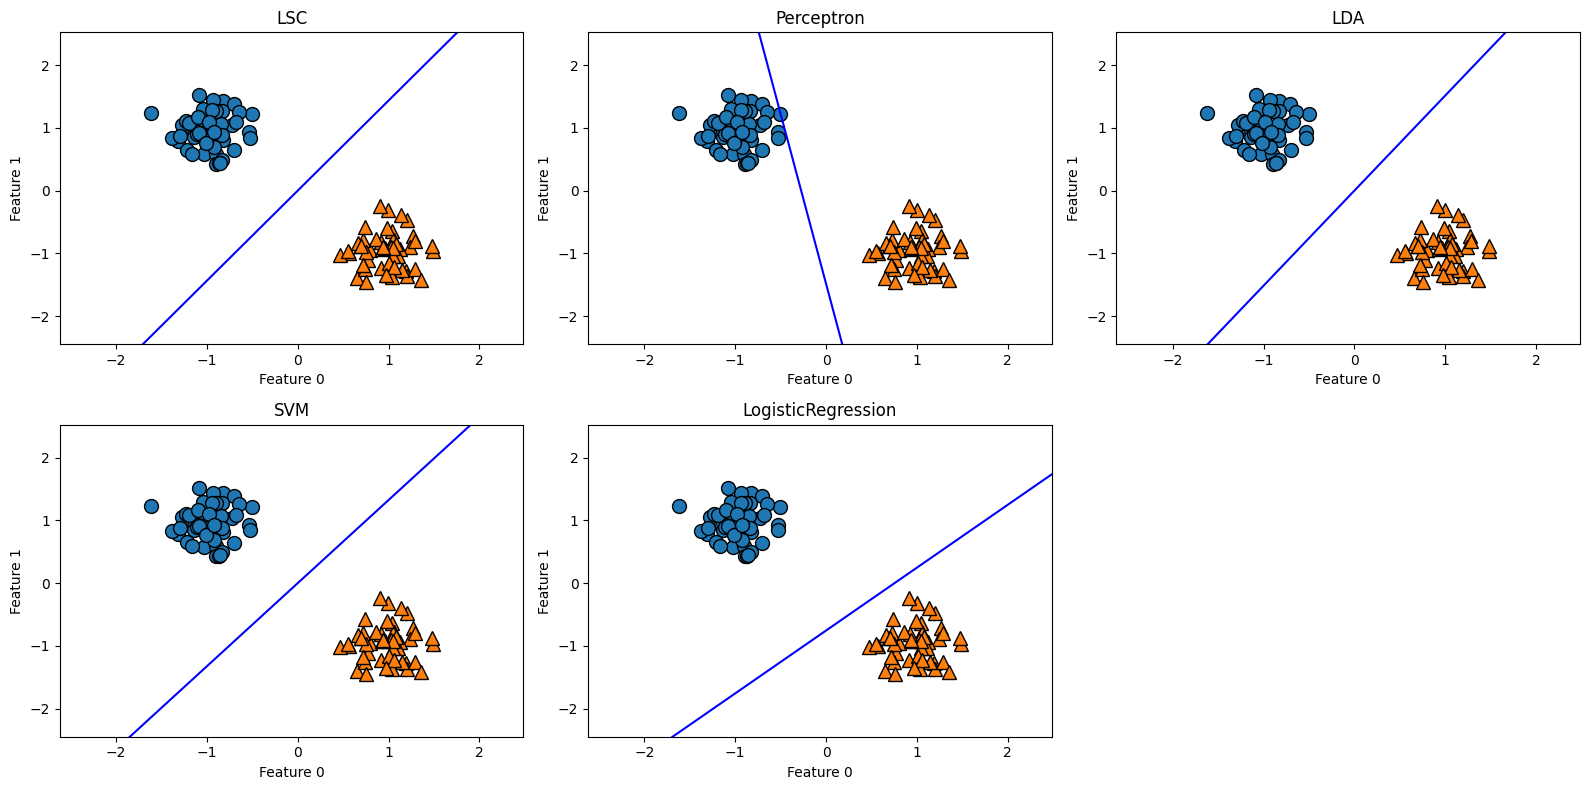

In [6]:
visualize_binary_classification(X, y, models, titles)

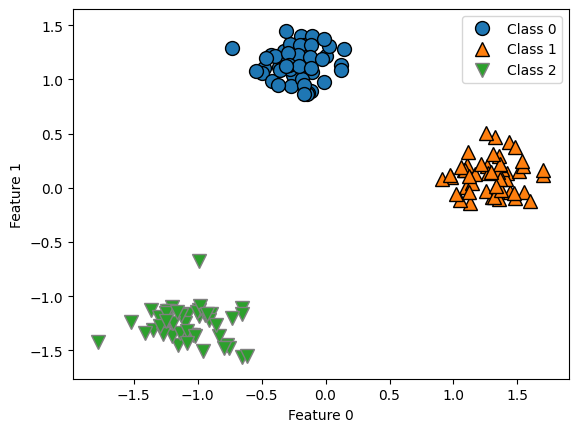

In [7]:
# 生成只有三个类别的二维玩具数据集
X3, y3 = make_blobs(n_samples=150, centers=3, random_state=42)

# 对数据进行归一化
scaler = StandardScaler()
X3 = scaler.fit_transform(X3)

# 使用PolynomialFeatures加一列1
poly = PolynomialFeatures(degree=1, include_bias=True)
X3 = poly.fit_transform(X3)

# 可视化数据点
mglearn.discrete_scatter(X3[:, 1], X3[:, 2], y3)
plt.xlabel("Feature 0")
plt.ylabel("Feature 1")
plt.legend(["Class 0", "Class 1", "Class 2"])
plt.show()

In [8]:
def visualize_multiclass_classification(X, y, model, titles):
    plt.figure(figsize=(16, 8))
    for i, model in enumerate(models):
        plt.subplot(2, 3, i + 1)
        mglearn.plots.plot_2d_classification(model, X[:, 1:3], fill=True, alpha=.7)
        mglearn.discrete_scatter(X[:, 1], X[:, 2], y)
        if isinstance(model, OvR):
            line = np.linspace(X[:, 1].min() - 1, X[:, 2].max() + 1, 100)
            for j, m in enumerate(model.models):
                coef = m.w
                plt.plot(line, -(line * coef[1] + coef[0]) / coef[2], label=f"Hyperplane {j}")
            plt.legend(loc=(1.01, 0.3))
        plt.xlabel("Feature 0")
        plt.ylabel("Feature 1")
        plt.title(f"{titles[i]}")
    plt.tight_layout()
    plt.show()

In [9]:
models = [OvR(LSC), OvR(Perceptron), OvR(LDA), OvR(SVM), SoftmaxRegression()]
titles = ['OvR-LSC', "OvR-Perceptron", "OvR-LDA", "OvR-SVM", "SoftmaxRegression"]
for _, model in enumerate(models):
    model.fit(X3, y3)

100%|██████████| 1000/1000 [00:00<00:00, 6099.74it/s]


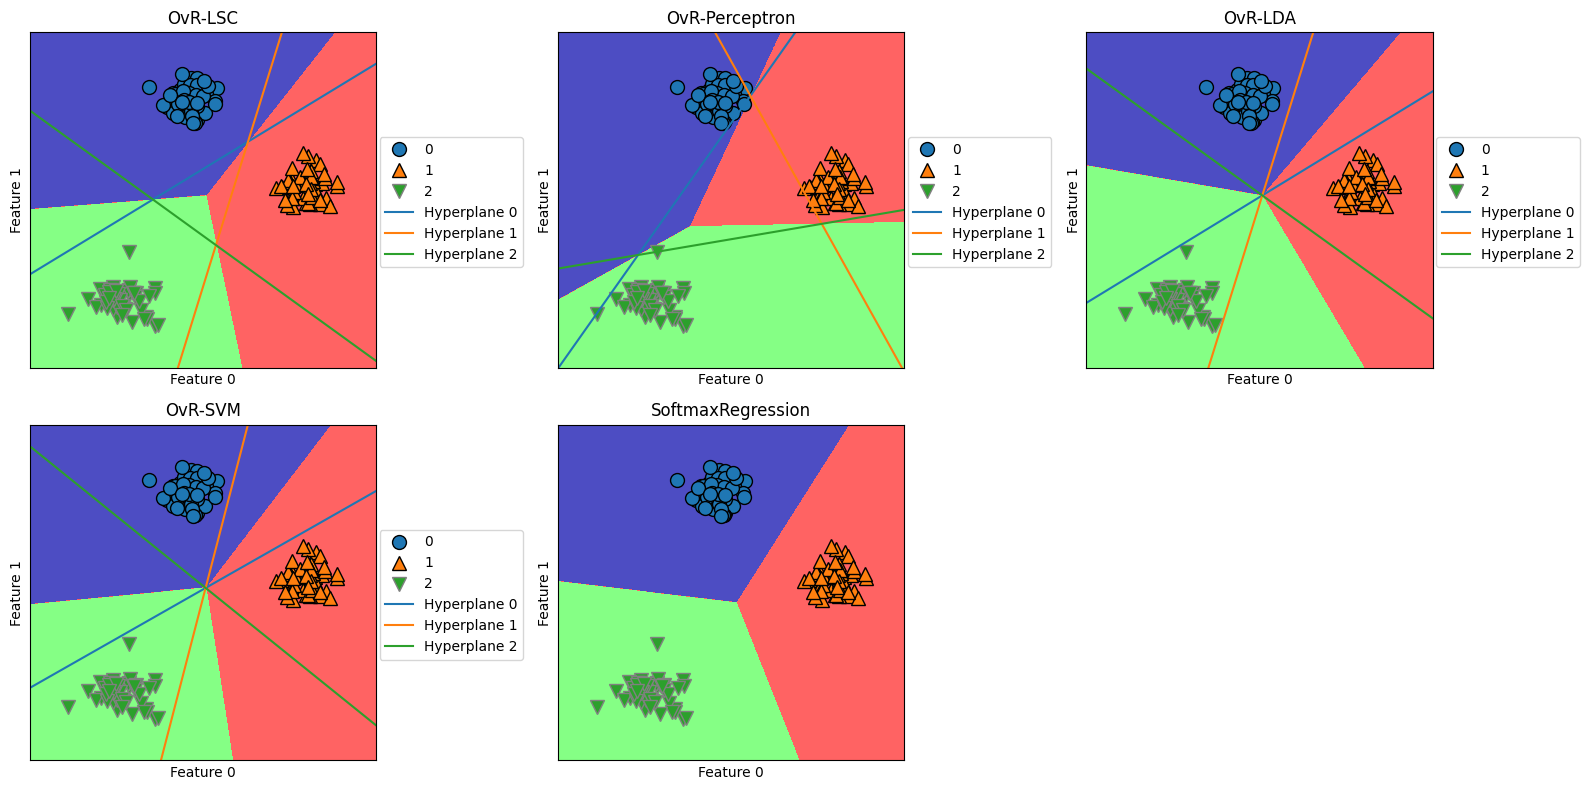

In [10]:
visualize_multiclass_classification(X3, y3, models, titles)

nTrain:60000 trainData:(60000, 784) trainLabel:(60000,)
nTest:10000 testData:(10000, 784) testLabel:(10000,)


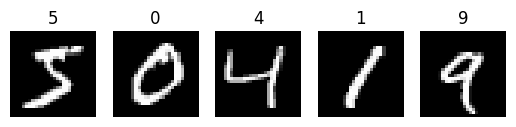

In [39]:
# 加载训练集和测试集
trainset = datasets.MNIST(root='./data', train=True, download=True)
testset  = datasets.MNIST(root='./data', train=False, download=True)
nTrain = trainset.data.shape[0]
trainData = trainset.data.numpy().reshape(nTrain, -1)
trainLabel = trainset.targets.numpy()
nTest = testset.data.shape[0]
testData = testset.data.numpy().reshape(nTest, -1)
testLabel = testset.targets.numpy()
print(f'nTrain:{nTrain} trainData:{trainData.shape} trainLabel:{trainLabel.shape}')
print(f'nTest:{nTest} testData:{testData.shape} testLabel:{testLabel.shape}')

# 预览数据
for i in range(5):
    plt.subplot(1, 5, i+1)
    plt.imshow(trainData[i].reshape(28, 28), cmap='gray')
    plt.axis('off')
    plt.title(trainLabel[i])
plt.show()

# 数据预处理: 归一化至 [-1, 1]
trainData = (trainData / 255.0) * 2 - 1
testData = (testData / 255.0) * 2 - 1

# PCA降维
pca = PCA(n_components=50)
trainData_pca = pca.fit_transform(trainData)
testData_pca = pca.transform(testData)

In [29]:
def visualize_mnist_classification(testData, testLabel, models, titles):
    plt.figure(figsize=(16, 8))
    for i, m in enumerate(models):
        predLabel = m.predict(testData)
        accuracy = accuracy_score(testLabel, predLabel)
        print(f"{titles[i]} (Accuracy: {accuracy * 100:.2f}%)")
        pca = PCA(n_components=2)
        testData2d = pca.fit_transform(testData)
        plt.subplot(2, 3, i + 1)
        plt.scatter(testData2d[:, 0], testData2d[:, 1], c=predLabel, cmap='viridis', s=10)
        plt.colorbar(label="Predicted Label")
        plt.xlabel("Feature 1")
        plt.ylabel("Feature 2")
        plt.title(f"{titles[i]} (Accuracy: {accuracy * 100:.2f}%)")
    plt.tight_layout()
    plt.show()

In [13]:
models = [OvR(LSC), OvR(Perceptron), OvR(LDA), OvR(SVM), SoftmaxRegression()]
titles = ['OvR-LSC', "OvR-Perceptron", "OvR-LDA", "OvR-SVM", "SoftmaxRegression"]
slice = 10000
for _, model in enumerate(models):
    model.fit(trainData_pca[:slice], trainLabel[:slice])

100%|██████████| 1000/1000 [00:05<00:00, 170.80it/s]


OvR-LSC (Accuracy: 84.95%)
OvR-Perceptron (Accuracy: 67.24%)
OvR-LDA (Accuracy: 82.63%)
OvR-SVM (Accuracy: 70.45%)
SoftmaxRegression (Accuracy: 74.48%)


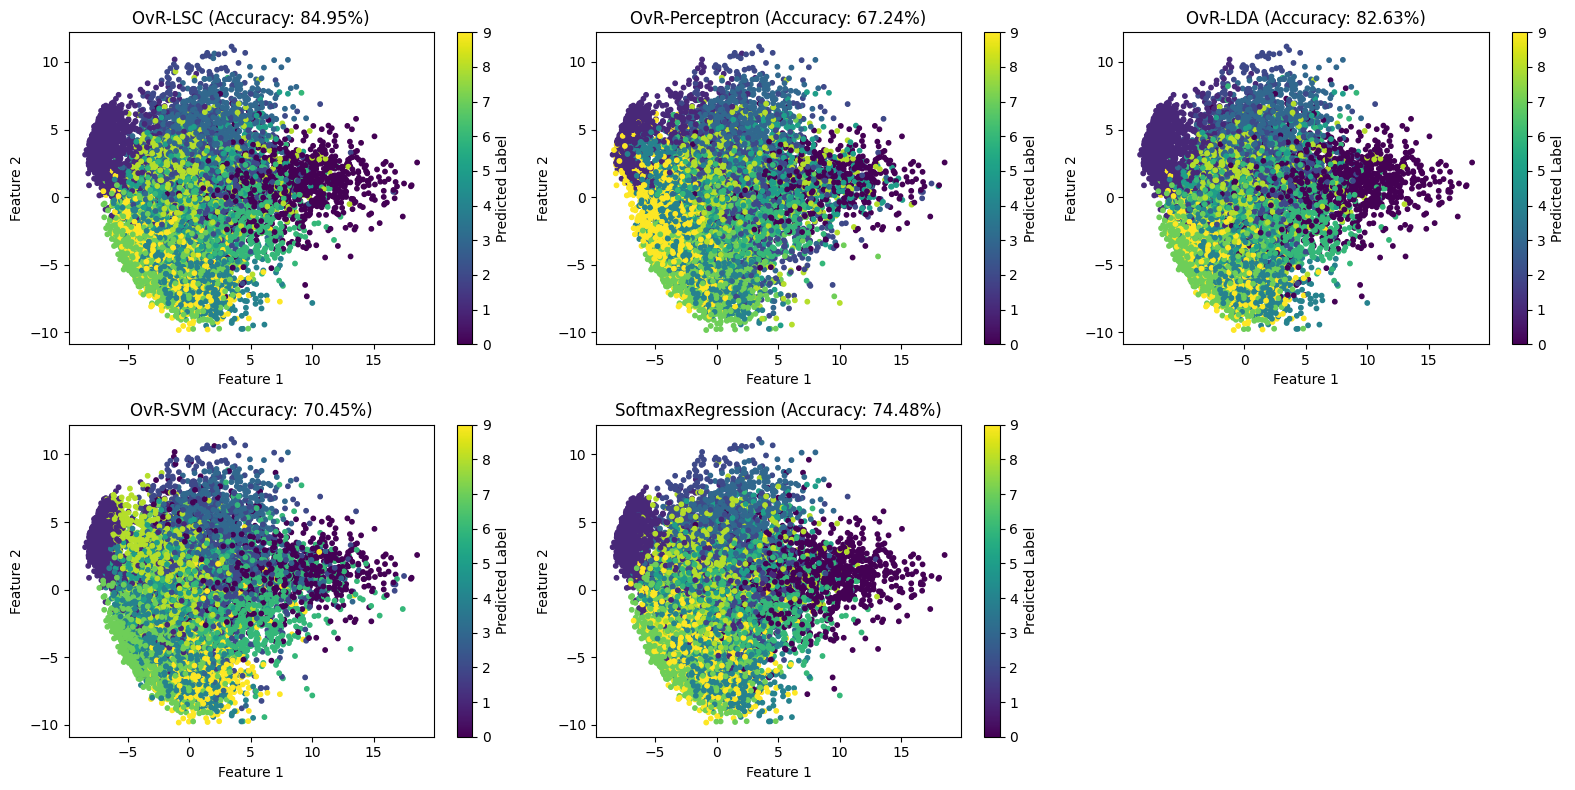

In [14]:
visualize_mnist_classification(testData_pca, testLabel, models, titles)

In [18]:
models = [PolyKernel(OvR(LSC)), PolyKernel(OvR(Perceptron)), PolyKernel(OvR(LDA)), PolyKernel(OvR(SVM)), PolyKernel(SoftmaxRegression())]
titles = ['OvR-LSC with PolyKernel', "OvR-Perceptron with PolyKernel", "OvR-LDA with PolyKernel", "OvR-SVM with PolyKernel", "SoftmaxRegression with PolyKernel"]
slice = 10000
for _, model in enumerate(models):
    model.fit(trainData_pca[:slice], trainLabel[:slice])

100%|██████████| 1000/1000 [00:09<00:00, 107.71it/s]


OvR-LSC with PolyKernel (Accuracy: 89.39%)
OvR-Perceptron with PolyKernel (Accuracy: 90.66%)
OvR-LDA with PolyKernel (Accuracy: 87.15%)
OvR-SVM with PolyKernel (Accuracy: 92.65%)
SoftmaxRegression with PolyKernel (Accuracy: 39.06%)


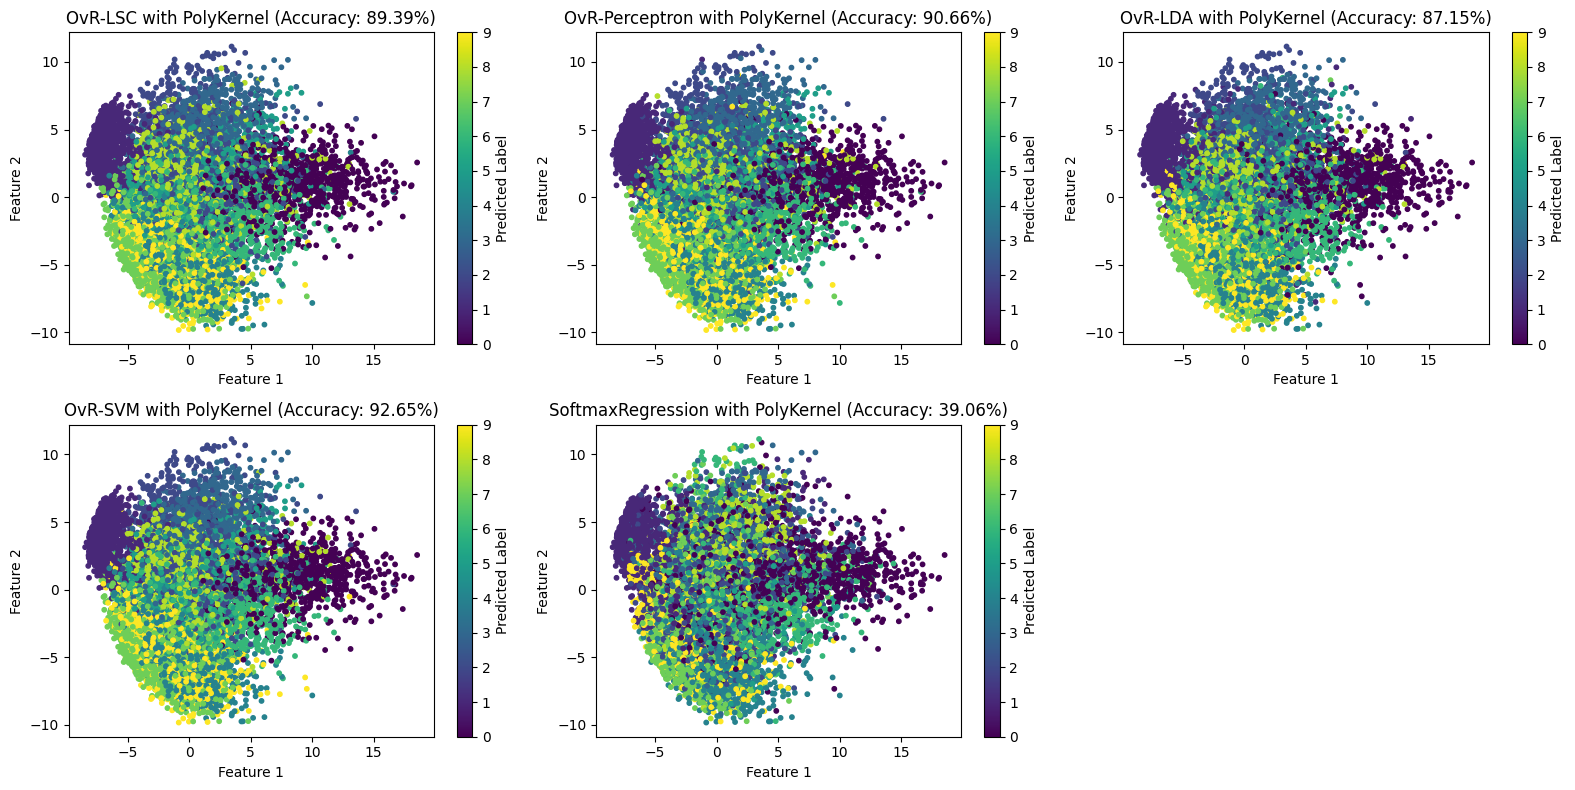

In [19]:
visualize_mnist_classification(testData_pca, testLabel, models, titles)

In [3]:
# 补充实验:MLP

class Module:
    def __call__(self, input):
        return self.forward(input)

    def forward(self, input):
        raise NotImplementedError

    def backward(self, output_grad):
        raise NotImplementedError

class Loss:
    def __call__(self, input, target):
        return self.forward(input, target)

    def forward(self, input, target):
        raise NotImplementedError

    def backward(self):
        raise NotImplementedError

class Optimizer:
    pass

def he_init(fan_in, shape):
    std_dev = np.sqrt(2 / (fan_in))
    return np.random.normal(0.0, std_dev, size=(shape))

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def softmax(x):
    if x.ndim == 2:
        x = x.T
        x = x - np.max(x, axis=0)
        y = np.exp(x) / np.sum(np.exp(x), axis=0)
        return y.T 

    x = x - np.max(x) # 溢出对策
    return np.exp(x) / np.sum(np.exp(x))

class Flatten(Module):
    def __init__(self):
        self.input_shape = None

    def forward(self, input):
        self.input_shape = input.shape
        return input.reshape(input.shape[0], -1)

    def backward(self, output_grad):
        return output_grad.reshape(self.input_shape)

class Linear(Module):
    def __init__(self, name, in_features, out_features, bias=True):
        self.name = name
        self.in_features = in_features
        self.out_features = out_features
        self.bias = bias

        self.input = None
        self.params = {} 
        self.params['W'] = he_init(in_features, (out_features, in_features))
        self.params['b'] = None
        if bias:
            self.params['b'] = he_init(in_features, (out_features))
        self.grads = {}
        self.grads['W'] = None
        self.grads['b'] = None

    def forward(self, input):
        self.input = input
        output = self.input @ self.params['W'].T
        if self.bias:
            output += self.params['b']
        return output

    def backward(self, output_grad):
        self.grads['W'] = output_grad.reshape(-1, self.out_features).T @ self.input.reshape(-1, self.in_features)
        if self.bias:
            self.grads['b'] = np.sum(output_grad, axis=tuple(range(output_grad.ndim - 1)))
        input_grad = output_grad @ self.params['W']
        return input_grad

class Sigmoid(Module):
    def __init__(self):
        self.output = None

    def forward(self, input):
        output = sigmoid(input)
        self.output = output
        return output

    def backward(self, output_grad):
        input_grad = output_grad * (1.0 - self.output) * self.output
        return input_grad

class CrossEntropyLoss(Loss):
    def __init__(self, model=None, reduction='mean'):
        self.model = model
        self.reduction = reduction

        self.input = None
        self.target = None

    def forward(self, input, target):
        input = softmax(input)
        self.input = input
        self.target = target

        if input.ndim == 1:
            target = target.reshape(1, target.size)
            input = input.reshape(1, input.size)
        
        # 监督数据是one-hot-vector的情况下，转换为正确解标签的索引
        if target.size == input.size:
            target = target.argmax(axis=1)
        
        batch_size = input.shape[0]
        loss = -np.sum(np.log(input[np.arange(batch_size), target] + 1e-7))

        if self.reduction == 'mean':
            loss = np.mean(loss) / batch_size

        return loss

    def backward(self):
        batch_size = self.target.shape[0]
        if self.target.size == self.input.size: # 监督数据是one-hot-vector的情况
            input_grad = (self.input - self.target)
        else:
            input_grad = self.input.copy()
            input_grad[np.arange(batch_size), self.target] -= 1

        if self.reduction == 'mean':
            input_grad /= batch_size
        
        if self.model is None:
            return input_grad
        else:
            self.model.backward(input_grad)

class SGD(Optimizer):
    def __init__(self, model, lr=1e-2):
        self.model = model
        self.lr = lr

    def zero_grad(self):
        for layer in self.model.layers:
            if hasattr(layer, 'params') and isinstance(layer.params, dict):
                for key, val in layer.params.items():
                    layer.grads[key] = np.zeros_like(val)

    def step(self):
        for layer in self.model.layers:
            if hasattr(layer, 'params') and isinstance(layer.params, dict):
                for key in layer.params.keys():
                    layer.params[key] -= self.lr * layer.grads[key]

def save_model(model, model_path):
    params = {}
    for layer in model.layers:
        if hasattr(layer, 'params') and isinstance(layer.params, dict):
            params[layer.name] = layer.params
    with open(model_path, 'wb') as fout:
        pickle.dump(params, fout)

def load_model(model, model_path):
    with open(model_path, 'rb') as fin:
        params = pickle.load(fin)
    for layer in model.layers:
        if hasattr(layer, 'params') and isinstance(layer.params, dict):
            layer.params = params[layer.name]

class Trainer(object):
    def __init__(self, 
        train_loader, valid_loader,
        model, model_path,
        optimizer, criterion, epochs 
    ):
        self.train_loader = train_loader
        self.valid_loader = valid_loader

        self.model = model
        self.model_path = model_path

        self.optimizer = optimizer
        self.criterion = criterion
        self.epochs = epochs

        self.train_loss = []
        self.valid_loss = []
        self.train_acc = []
        self.valid_acc = []
        self.best_train_loss = np.inf
        self.best_valid_loss = np.inf
        self.best_train_acc = 0
        self.best_valid_acc = 0

        self.plateau_counter = 0

    def train(self):
        best_acc = 0
        for epoch in range(self.epochs):
            self._train_step(epoch)
            self._valid_step(epoch)
            self._show_info()
            if best_acc < self.valid_acc[-1]:
                best_acc = self.valid_acc[-1]
                self.plateau_counter = 0
                print(f'Saving model ...')
                save_model(self.model, self.model_path)
            else:
                self.plateau_counter += 1
                print(f'In plateau: {self.plateau_counter}')
        self._summarize()

    def _train_step(self, epoch):
        train_epoch_loss = []
        correct_pred = 0
        total_pred = 0
        for _, (inputs, labels) in enumerate(tqdm(self.train_loader, desc=f"[train] Epoch {epoch + 1} of {self.epochs}", leave=True, ncols=80)):
            inputs = inputs.numpy()
            labels = labels.numpy()
            outputs = self.model(inputs)

            self.optimizer.zero_grad()
            loss = self.criterion(outputs, labels)
            self.criterion.backward() # loss.backward() in pytorch
            self.optimizer.step()
            
            train_epoch_loss.append(loss.item())
            predictions = np.argmax(outputs, 1)
            for label, prediction in zip(labels, predictions):
                if label == prediction:
                    correct_pred += 1
                total_pred += 1
        self.train_loss.append(np.average(train_epoch_loss))
        self.best_train_loss = min(self.best_train_loss, self.train_loss[-1])
        self.train_acc.append(correct_pred / total_pred)
        self.best_train_acc = max(self.best_train_acc, self.train_acc[-1])

    def _valid_step(self, epoch):
        valid_epoch_loss = []
        correct_pred = 0
        total_pred = 0
        for _, (inputs, labels) in enumerate(tqdm(self.valid_loader, desc=f"[valid] Epoch {epoch + 1} of {self.epochs}", leave=True, ncols=80)):
            inputs = inputs.numpy()
            labels = labels.numpy()
            outputs = self.model(inputs)

            loss = self.criterion(outputs, labels)
            
            valid_epoch_loss.append(loss.item())
            predictions = np.argmax(outputs, 1)
            for label, prediction in zip(labels, predictions):
                if label == prediction:
                    correct_pred += 1
                total_pred += 1
        self.valid_loss.append(np.average(valid_epoch_loss))
        self.best_valid_loss = min(self.best_valid_loss, self.valid_loss[-1])
        self.valid_acc.append(np.average(correct_pred / total_pred))
        self.best_valid_acc = max(self.best_valid_acc, self.valid_acc[-1])

    def _show_info(self):
        column_width = 11
        print('| ', end='')
        print(''.center(column_width), end=' | ')
        print('train_loss'.center(column_width), end=' | ')
        print('train_acc'.center(column_width), end=' | ')
        print('valid_loss'.center(column_width), end=' | ')
        print('valid_acc'.center(column_width), end=' | ')
        print()
        print('+ ', end='')
        print(('-' * column_width + ' + ') * 5)
        print('| ', end='')
        print('current'.center(column_width), end=' | ')
        print(f'{self.train_loss[-1]:.6f}'.center(column_width), end=' | ')
        print(f'{self.train_acc[-1]*100:.4f}%'.center(column_width), end=' | ')
        print(f'{self.valid_loss[-1]:.6f}'.center(column_width), end=' | ')
        print(f'{self.valid_acc[-1]*100:.4f}%'.center(column_width), end=' | ')
        print()
        print('| ', end='')
        print('best'.center(column_width), end=' | ')
        print(f'{self.best_train_loss:.6f}'.center(column_width), end=' | ')
        print(f'{self.best_train_acc*100:.4f}%'.center(column_width), end=' | ')
        print(f'{self.best_valid_loss:.6f}'.center(column_width), end=' | ')
        print(f'{self.best_valid_acc*100:.4f}%'.center(column_width), end=' | ')
        print()

    def _summarize(self):
        plt.figure(figsize=(12,4))
        plt.subplot(121)
        plt.plot(np.arange(1, len(self.train_loss) + 1), self.train_loss, label="train_loss")
        plt.plot(np.arange(1, len(self.valid_loss) + 1), self.valid_loss, label="valid_loss")
        plt.title("epoch_loss")
        plt.subplot(122)
        plt.plot(np.arange(1, len(self.train_acc) + 1), self.train_acc, label="train_acc")
        plt.plot(np.arange(1, len(self.valid_acc) + 1), self.valid_acc, label="valid_acc")
        plt.title("epoch_acc")
        plt.legend()
        plt.show()

class Tester(object):
    def __init__(self, test_loader, model):
        self.test_loader = test_loader
        self.model = model

    def test(self):
        correct_pred = 0
        total_pred = 0
        for _, (inputs, labels) in enumerate(tqdm(self.test_loader, desc=f"[test]", leave=True, ncols=80)):
            inputs = inputs.numpy()
            labels = labels.numpy()
            outputs = self.model(inputs)
            predictions = np.argmax(outputs, 1)
            for label, prediction in zip(labels, predictions):
                if label == prediction:
                    correct_pred += 1
                total_pred += 1
        print(f'Accuracy: {(correct_pred / total_pred) * 100:.4f}%')

In [12]:
# 设置参数
class DefaultArgs(object):
    # mnist
    num_classes = 10
    class_name = ('0', '1', '2', '3', '4', '5', '6', '7', '8', '9')
    data_path = './data'
    model_path = './mnist.pth'

    # 数据处理超参
    valid_percent = 0.05
    num_workers = 2

    # 训练超参
    epochs = 60
    batch_size = {'train':30,'valid':100,'test':100}
    optimizer = {'name':'SGD', 'learning_rate':1e-2}

args = DefaultArgs()

# PIL转换为Tensor并标准化
normal_transform = transforms.Compose([
    transforms.ToTensor(), # 将图像转为 [0, 1] 范围的 Tensor
    transforms.Normalize((0.5,), (0.5,)) # 将 [0, 1] 归一化为 [-1, 1]
])

trainset = torchvision.datasets.MNIST(root=args.data_path, train=True, download=True, transform=normal_transform)
validset = torchvision.datasets.MNIST(root=args.data_path, train=True, download=True, transform=normal_transform)
testset = torchvision.datasets.MNIST(root=args.data_path, train=False, download=True, transform=normal_transform)
total_len = len(trainset)
total_len = 10000
validset_idx = np.arange(0, total_len * args.valid_percent).astype(np.int32).tolist()
trainset_idx = np.arange(total_len * args.valid_percent, total_len).astype(np.int32).tolist()
trainset = Subset(trainset, trainset_idx)
validset = Subset(validset, validset_idx)
print(f'num_trainset={len(trainset)}')
print(f'num_validset={len(validset)}')
print(f'num_testset={len(testset)}')

train_loader = DataLoader(trainset, batch_size=args.batch_size['train'], shuffle=True, num_workers=args.num_workers)
valid_loader = DataLoader(validset, batch_size=args.batch_size['valid'], shuffle=False, num_workers=args.num_workers)
test_loader = DataLoader(testset, batch_size=args.batch_size['test'], shuffle=False, num_workers=args.num_workers)

# 定义自己的模型
class net:
    def __init__(self):
        self.layers = [ # 1*28*28
            Flatten(),
            Linear('fc1', 1*28*28, 100),
            Sigmoid(),
            Linear('fc2', 100, 50),
            Sigmoid(),
            Linear('fc3', 50, 10)
        ]

    def __call__(self, input):
        return self.forward(input)
    
    def forward(self, input):
        output = input
        for layer in self.layers:
            output = layer.forward(output)
        return output
    
    def backward(self, output_grad):
        input_grad = output_grad
        for layer in reversed(self.layers):
            input_grad = layer.backward(input_grad)

    def predict(self, input):
        outputs = self(input)
        return np.argmax(outputs, 1)

# 实例化模型，设置loss，优化器等
model = net()
criterion = CrossEntropyLoss(model)
optimizer = SGD(model, lr=args.optimizer['learning_rate'])

num_trainset=9500
num_validset=500
num_testset=10000


[valid] Epoch 1 of 60: 100%|██████████████████████| 5/5 [00:12<00:00,  2.42s/it]


|             |  train_loss |  train_acc  |  valid_loss |  valid_acc  | 
+ ----------- + ----------- + ----------- + ----------- + ----------- + 
|   current   |   2.263856  |   24.8421%  |   2.177957  |   48.2000%  | 
|     best    |   2.263856  |   24.8421%  |   2.177957  |   48.2000%  | 
Saving model ...


[valid] Epoch 2 of 60: 100%|██████████████████████| 5/5 [00:10<00:00,  2.17s/it]


|             |  train_loss |  train_acc  |  valid_loss |  valid_acc  | 
+ ----------- + ----------- + ----------- + ----------- + ----------- + 
|   current   |   2.109260  |   51.1368%  |   2.013299  |   57.6000%  | 
|     best    |   2.109260  |   51.1368%  |   2.013299  |   57.6000%  | 
Saving model ...


[valid] Epoch 3 of 60: 100%|██████████████████████| 5/5 [00:10<00:00,  2.16s/it]


...

|             |  train_loss |  train_acc  |  valid_loss |  valid_acc  | 
+ ----------- + ----------- + ----------- + ----------- + ----------- + 
|   current   |   0.259081  |   93.1579%  |   0.280956  |   91.8000%  | 
|     best    |   0.259081  |   93.1579%  |   0.280956  |   92.2000%  | 
In plateau: 2


[valid] Epoch 59 of 60: 100%|█████████████████████| 5/5 [00:16<00:00,  3.21s/it]


|             |  train_loss |  train_acc  |  valid_loss |  valid_acc  | 
+ ----------- + ----------- + ----------- + ----------- + ----------- + 
|   current   |   0.257058  |   93.2632%  |   0.283985  |   91.8000%  | 
|     best    |   0.257058  |   93.2632%  |   0.280956  |   92.2000%  | 
In plateau: 3


[valid] Epoch 60 of 60: 100%|█████████████████████| 5/5 [00:16<00:00,  3.28s/it]


|             |  train_loss |  train_acc  |  valid_loss |  valid_acc  | 
+ ----------- + ----------- + ----------- + ----------- + ----------- + 
|   current   |   0.254720  |   93.4421%  |   0.281194  |   91.8000%  | 
|     best    |   0.254720  |   93.4421%  |   0.280956  |   92.2000%  | 
In plateau: 4


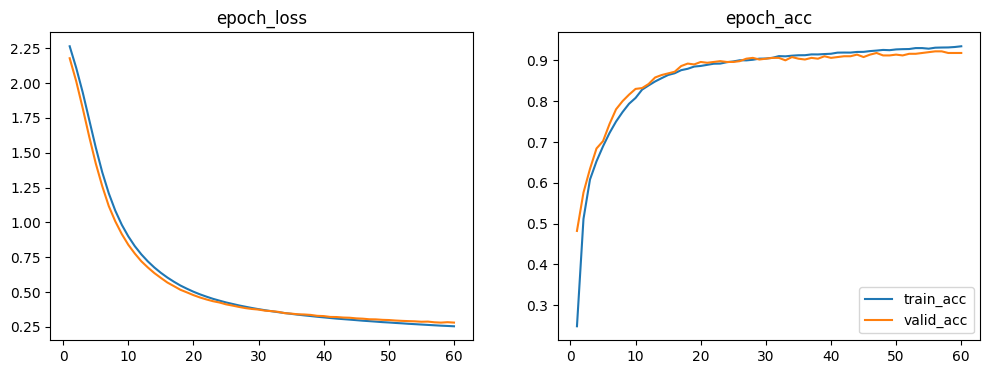

In [13]:
trainer = Trainer(train_loader, valid_loader, model, args.model_path, optimizer, criterion, args.epochs)
trainer.train()

In [14]:
model = net()
load_model(model, args.model_path)
tester = Tester(test_loader, model)
tester.test()

[test]: 100%|█████████████████████████████████| 100/100 [00:18<00:00,  5.53it/s]

Accuracy: 91.3500%


In [15]:
# 加载训练集和测试集
trainset = datasets.MNIST(root='./data', train=True, download=True)
testset  = datasets.MNIST(root='./data', train=False, download=True)
nTrain = trainset.data.shape[0]
trainData = trainset.data.numpy().reshape(nTrain, -1)
trainLabel = trainset.targets.numpy()
nTest = testset.data.shape[0]
testData = testset.data.numpy().reshape(nTest, -1)
testLabel = testset.targets.numpy()
print(f'nTrain:{nTrain} trainData:{trainData.shape} trainLabel:{trainLabel.shape}')
print(f'nTest:{nTest} testData:{testData.shape} testLabel:{testLabel.shape}')

# 数据预处理: 归一化至 [-1, 1]
trainData = (trainData / 255.0) * 2 - 1
testData = (testData / 255.0) * 2 - 1

# PCA降维
pca = PCA(n_components=50)
trainData_pca = pca.fit_transform(trainData)
testData_pca = pca.transform(testData)

models = [PolyKernel(OvR(LSC)), PolyKernel(OvR(Perceptron)), PolyKernel(OvR(LDA)), PolyKernel(OvR(SVM)), PolyKernel(SoftmaxRegression()), net()]
titles = ['OvR-LSC with PolyKernel', "OvR-Perceptron with PolyKernel", "OvR-LDA with PolyKernel", "OvR-SVM with PolyKernel", "SoftmaxRegression with PolyKernel", "MLP"]
slice = 10000
for _, model in enumerate(models):
    if isinstance(model, net):
        load_model(model, args.model_path)
    else:
        model.fit(trainData_pca[:slice], trainLabel[:slice])

nTrain:60000 trainData:(60000, 784) trainLabel:(60000,)
nTest:10000 testData:(10000, 784) testLabel:(10000,)


100%|██████████| 1000/1000 [00:15<00:00, 64.92it/s]


In [16]:
def visualize_mnist_classification_withMLP(testData_pca, testData, testLabel, models, titles):
    plt.figure(figsize=(16, 8))
    for i, m in enumerate(models):
        if isinstance(m, net):
            predLabel = m.predict(testData)
        else:
            predLabel = m.predict(testData_pca)
        accuracy = accuracy_score(testLabel, predLabel)
        print(f"{titles[i]} (Accuracy: {accuracy * 100:.2f}%)")
        pca = PCA(n_components=2)
        testData2d = pca.fit_transform(testData_pca)
        plt.subplot(2, 3, i + 1)
        plt.scatter(testData2d[:, 0], testData2d[:, 1], c=predLabel, cmap='viridis', s=10)
        plt.colorbar(label="Predicted Label")
        plt.xlabel("Feature 1")
        plt.ylabel("Feature 2")
        plt.title(f"{titles[i]} (Accuracy: {accuracy * 100:.2f}%)")
    plt.tight_layout()
    plt.show()

OvR-LSC with PolyKernel (Accuracy: 90.61%)
OvR-Perceptron with PolyKernel (Accuracy: 89.92%)
OvR-LDA with PolyKernel (Accuracy: 86.80%)
OvR-SVM with PolyKernel (Accuracy: 92.30%)
SoftmaxRegression with PolyKernel (Accuracy: 38.01%)
MLP (Accuracy: 91.35%)


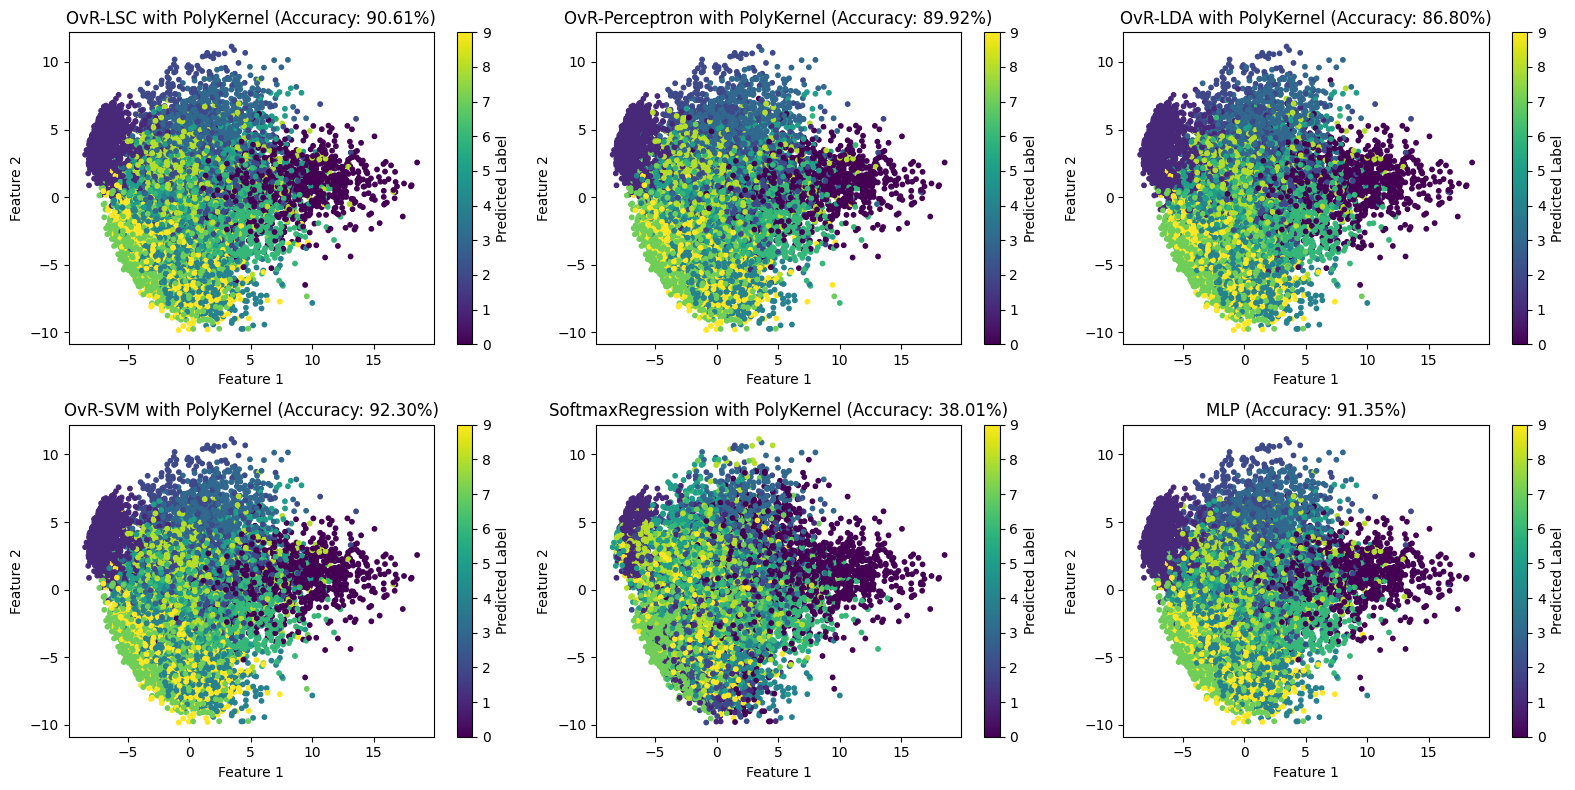

In [17]:
visualize_mnist_classification_withMLP(testData_pca, testData, testLabel, models, titles)